# 05 - Neural Network Classification

Goal: classify songs into Low, Medium, and High popularity categories using PyTorch. The target classes were created with quantile bins to keep the class distribution balanced.

In [1]:
from pathlib import Path
import warnings

from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings("ignore", category=PendingDeprecationWarning, module="seaborn")

SPOTIFY_GREEN = "#1DB954"
SPOTIFY_BLACK = "#191414"
SPOTIFY_GRAY = "#535353"
SPOTIFY_PALETTE = ["#1DB954", "#1ED760", "#0E7A37", "#73E68C", "#117A37", "#0A5C29"]
SPOTIFY_SEQ = LinearSegmentedColormap.from_list("spotify_seq", ["#FFFFFF", "#1DB954", "#0A4A22"])
SPOTIFY_DIVERGE = LinearSegmentedColormap.from_list("spotify_div", ["#191414", "#FFFFFF", "#1DB954"])


def apply_spotify_theme():
    import matplotlib as mpl
    import seaborn as sns

    sns.set_theme(style="whitegrid", palette=SPOTIFY_PALETTE)
    mpl.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.titleweight": "bold",
        "axes.titlecolor": SPOTIFY_BLACK,
        "axes.labelcolor": SPOTIFY_BLACK,
        "axes.edgecolor": "#C9C9C9",
        "grid.color": "#ECECEC",
        "text.color": SPOTIFY_BLACK,
        "font.size": 11,
        "axes.titlesize": 14,
        "figure.titlesize": 16,
        "figure.titleweight": "bold",
    })


PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_RAW = PROJECT_ROOT / "data" / "raw" / "dataset.csv"
DATA_CLEAN = PROJECT_ROOT / "data" / "processed" / "spotify_tracks_clean.csv"

RANDOM_STATE = 42

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder

apply_spotify_theme()
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

df = pd.read_csv(DATA_CLEAN)
print(df.shape)
display(df["popularity_class"].value_counts().sort_index().to_frame("count"))

(89741, 23)


,count
popularity_class,
High,29870
Low,31659
Medium,28212


## Architecture and Training Choices

The notebook compares the original compact feed-forward classifier against a tuned deeper architecture:

- Input layer equals the number of encoded features.
- Baseline hidden layers: 128 neurons then 64 neurons.
- Tuned hidden layers: 256 neurons, 128 neurons, then 64 neurons.
- ReLU activations are used because they train efficiently and handle nonlinear feature relationships.
- Dropout and AdamW weight decay provide regularization.
- Cross-entropy loss is used because this is a multiclass classification problem.
- Early stopping prevents overfitting by stopping when validation loss stops improving.

In [3]:
numeric_features = [
    "duration_min", "is_explicit", "danceability", "energy", "key", "loudness",
    "mode", "speechiness", "acousticness", "instrumentalness", "liveness",
    "valence", "tempo", "time_signature"
]
categorical_features = ["track_genre"]

X = df[numeric_features + categorical_features]
y = df["popularity_class"].astype(str)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=y_encoded
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train
)

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("genre", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", encoder)
        ]), categorical_features)
    ]
)

X_train_np = preprocessor.fit_transform(X_train).astype(np.float32)
X_val_np = preprocessor.transform(X_val).astype(np.float32)
X_test_np = preprocessor.transform(X_test).astype(np.float32)

print(f"Encoded feature count: {X_train_np.shape[1]}")

Encoded feature count: 127


In [4]:
class PopularityClassifier(nn.Module):
    def __init__(self, input_dim, n_classes, hidden_layers, dropout_rates):
        super().__init__()
        layers = []
        previous = input_dim
        for i, width in enumerate(hidden_layers):
            layers.append(nn.Linear(previous, width))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rates[i]))
            previous = width
        layers.append(nn.Linear(previous, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def specificity_macro(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    specs = []
    for i in range(cm.shape[0]):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = cm.sum() - tp - fp - fn
        specs.append(tn / (tn + fp) if (tn + fp) else 0)
    return float(np.mean(specs))


def evaluate_predictions(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision,
        "recall": recall,
        "specificity": specificity_macro(y_true, y_pred),
        "f1": f1,
    }


def train_experiment(
    name,
    hidden_layers,
    dropout_rates,
    optimizer_name,
    lr,
    weight_decay,
    batch_size,
    max_epochs,
    patience,
):
    torch.manual_seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)

    train_loader = DataLoader(
        TensorDataset(torch.tensor(X_train_np), torch.tensor(y_train, dtype=torch.long)),
        batch_size=batch_size,
        shuffle=True,
    )
    val_tensor = torch.tensor(X_val_np)
    test_tensor = torch.tensor(X_test_np)

    model = PopularityClassifier(
        X_train_np.shape[1],
        len(label_encoder.classes_),
        hidden_layers=hidden_layers,
        dropout_rates=dropout_rates,
    )
    criterion = nn.CrossEntropyLoss()
    if optimizer_name == "AdamW":
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_loss = np.inf
    best_state = None
    patience_counter = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_losses = []
        correct = 0
        total = 0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())
            correct += (logits.argmax(dim=1) == yb).sum().item()
            total += len(yb)

        model.eval()
        with torch.no_grad():
            val_logits = model(val_tensor)
            val_loss = criterion(val_logits, torch.tensor(y_val, dtype=torch.long)).item()
            val_acc = (val_logits.argmax(dim=1).numpy() == y_val).mean()

        train_loss = float(np.mean(train_losses))
        train_acc = correct / total
        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_acc": train_acc,
            "val_acc": val_acc,
        })

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"{name}: early stopping at epoch {epoch}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    with torch.no_grad():
        train_pred = model(torch.tensor(X_train_np)).argmax(dim=1).numpy()
        test_pred = model(test_tensor).argmax(dim=1).numpy()

    history_df = pd.DataFrame(history)
    train_metrics = evaluate_predictions(y_train, train_pred)
    test_metrics = evaluate_predictions(y_test, test_pred)
    summary = {
        "model": name,
        "hidden_layers": str(hidden_layers),
        "optimizer": optimizer_name,
        "lr": lr,
        "weight_decay": weight_decay,
        "dropout": str(dropout_rates),
        "epochs": len(history_df),
        "best_val_loss": best_val_loss,
        "best_val_acc": history_df["val_acc"].max(),
        "train_accuracy": train_metrics["accuracy"],
        "test_accuracy": test_metrics["accuracy"],
        "precision": test_metrics["precision"],
        "recall": test_metrics["recall"],
        "specificity": test_metrics["specificity"],
        "f1": test_metrics["f1"],
    }
    return {
        "model": model,
        "history": history_df,
        "train_pred": train_pred,
        "test_pred": test_pred,
        "summary": summary,
    }


baseline_result = train_experiment(
    name="Original baseline NN",
    hidden_layers=(128, 64),
    dropout_rates=(0.25, 0.20),
    optimizer_name="Adam",
    lr=0.001,
    weight_decay=1e-4,
    batch_size=512,
    max_epochs=20,
    patience=4,
)

tuned_result = train_experiment(
    name="Tuned deep NN",
    hidden_layers=(256, 128, 64),
    dropout_rates=(0.20, 0.20, 0.20),
    optimizer_name="AdamW",
    lr=0.0008,
    weight_decay=1e-5,
    batch_size=1024,
    max_epochs=35,
    patience=6,
)

nn_comparison = pd.DataFrame([
    baseline_result["summary"],
    tuned_result["summary"],
])
baseline_test_acc = baseline_result["summary"]["test_accuracy"]
baseline_f1 = baseline_result["summary"]["f1"]
nn_comparison["accuracy_improvement"] = nn_comparison["test_accuracy"] - baseline_test_acc
nn_comparison["f1_improvement"] = nn_comparison["f1"] - baseline_f1
display(nn_comparison.round(4))

model = tuned_result["model"]
history_df = tuned_result["history"]
display(history_df.tail())

Tuned deep NN: early stopping at epoch 35


,model,hidden_layers,optimizer,lr,weight_decay,dropout,epochs,best_val_loss,best_val_acc,train_accuracy,test_accuracy,precision,recall,specificity,f1,accuracy_improvement,f1_improvement
0,Original baseline NN,"(128, 64)",Adam,0.0010,0.0001,"(0.25, 0.2)",20,0.7059,0.6819,0.7072,0.6814,0.6799,0.6769,0.8402,0.6750,0.0000,0.0000
1,Tuned deep NN,"(256, 128, 64)",AdamW,0.0008,0.0000,"(0.2, 0.2, 0.2)",35,0.6990,0.6863,0.7268,0.6886,0.6858,0.6849,0.8440,0.6842,0.0071,0.0091


,epoch,train_loss,val_loss,train_acc,val_acc
30,31,0.658204,0.699588,0.708182,0.681802
31,32,0.655019,0.701719,0.711995,0.683474
32,33,0.654864,0.700968,0.714032,0.685215
33,34,0.652882,0.699153,0.713649,0.686190
34,35,0.650105,0.702159,0.714328,0.684518


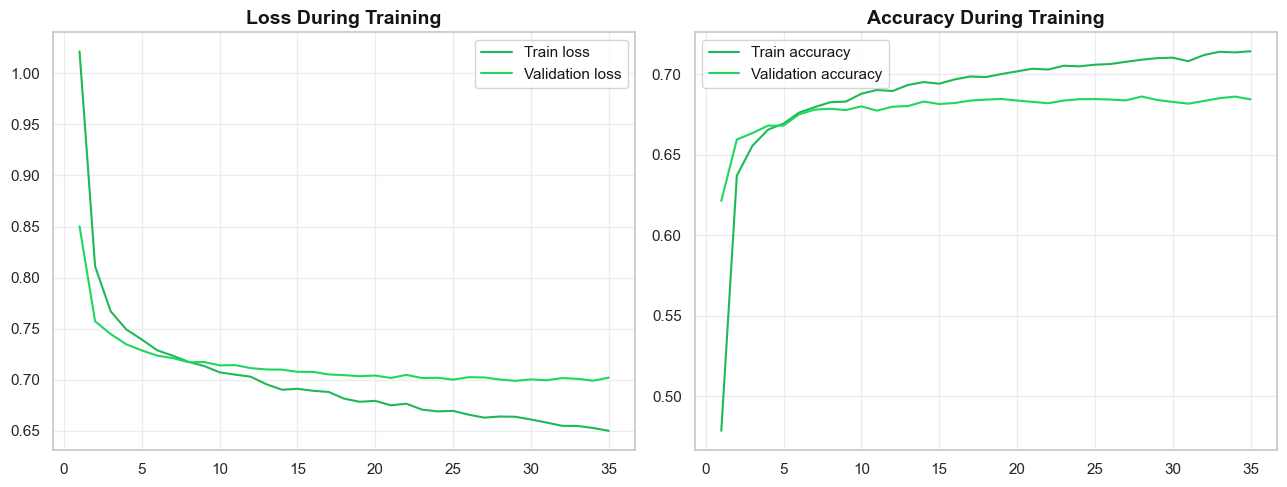

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Validation loss")
axes[0].set_title("Loss During Training")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_acc"], label="Train accuracy")
axes[1].plot(history_df["epoch"], history_df["val_acc"], label="Validation accuracy")
axes[1].set_title("Accuracy During Training")
axes[1].legend()
plt.tight_layout()
plt.show()

In [6]:
model.eval()
with torch.no_grad():
    train_pred = model(torch.tensor(X_train_np)).argmax(dim=1).numpy()
    test_pred = model(torch.tensor(X_test_np)).argmax(dim=1).numpy()

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, test_pred, average="macro", zero_division=0
)

metrics = pd.DataFrame({
    "metric": ["Accuracy", "Precision", "Recall", "Specificity", "F1 Score"],
    "test_value": [
        accuracy_score(y_test, test_pred),
        precision,
        recall,
        specificity_macro(y_test, test_pred),
        f1,
    ],
})

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

display(metrics.round(4))
print("Comparison against original baseline:")
display(nn_comparison[[
    "model", "test_accuracy", "precision", "recall", "specificity", "f1",
    "accuracy_improvement", "f1_improvement"
]].round(4))
print(f"Train accuracy: {train_accuracy:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

,metric,test_value
0,Accuracy,0.6886
1,Precision,0.6858
2,Recall,0.6849
3,Specificity,0.8440
4,F1 Score,0.6842


Comparison against original baseline:


,model,test_accuracy,precision,recall,specificity,f1,accuracy_improvement,f1_improvement
0,Original baseline NN,0.6814,0.6799,0.6769,0.8402,0.6750,0.0000,0.0000
1,Tuned deep NN,0.6886,0.6858,0.6849,0.8440,0.6842,0.0071,0.0091


Train accuracy: 0.7268
Test accuracy: 0.6886


Original baseline confusion matrix


,High,Low,Medium
High,4278,846,850
Low,784,4913,635
Medium,1366,1237,3040


Tuned deep neural network confusion matrix


,High,Low,Medium
High,4076,877,1021
Low,606,4954,772
Medium,1140,1174,3329


Baseline misclassified songs: 5,718
Tuned model misclassified songs: 5,590
Reduction in misclassified songs: 128


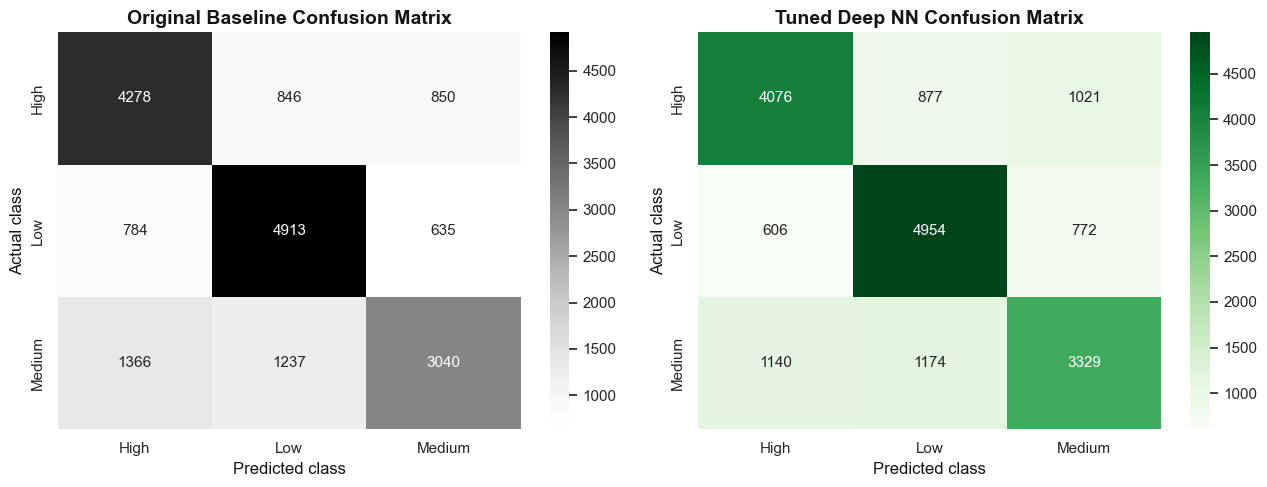

In [7]:
baseline_cm = confusion_matrix(y_test, baseline_result["test_pred"])
tuned_cm = confusion_matrix(y_test, test_pred)

baseline_cm_df = pd.DataFrame(baseline_cm, index=label_encoder.classes_, columns=label_encoder.classes_)
tuned_cm_df = pd.DataFrame(tuned_cm, index=label_encoder.classes_, columns=label_encoder.classes_)

print("Original baseline confusion matrix")
display(baseline_cm_df)
print("Tuned deep neural network confusion matrix")
display(tuned_cm_df)

baseline_errors = len(y_test) - np.trace(baseline_cm)
tuned_errors = len(y_test) - np.trace(tuned_cm)
print(f"Baseline misclassified songs: {baseline_errors:,}")
print(f"Tuned model misclassified songs: {tuned_errors:,}")
print(f"Reduction in misclassified songs: {baseline_errors - tuned_errors:,}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(baseline_cm_df, annot=True, fmt="d", cmap="Greys", ax=axes[0])
axes[0].set_title("Original Baseline Confusion Matrix")
axes[0].set_xlabel("Predicted class")
axes[0].set_ylabel("Actual class")

sns.heatmap(tuned_cm_df, annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("Tuned Deep NN Confusion Matrix")
axes[1].set_xlabel("Predicted class")
axes[1].set_ylabel("Actual class")
plt.tight_layout()
plt.show()

In [8]:
error_df = X_test.copy()
error_df["actual"] = label_encoder.inverse_transform(y_test)
error_df["predicted"] = label_encoder.inverse_transform(test_pred)
errors = error_df[error_df["actual"] != error_df["predicted"]]

error_pairs = (
    errors.groupby(["actual", "predicted"])
    .size()
    .sort_values(ascending=False)
    .to_frame("count")
)
display(error_pairs.head(10))

genre_errors = (
    errors["track_genre"]
    .value_counts()
    .head(10)
    .to_frame("misclassified_count")
)
display(genre_errors)

print("Interpretation:")
print("- Most classification errors occur near adjacent popularity bands because quantile classes split a continuous score into categories.")
print("- The tuned model uses a deeper 256-128-64 architecture, AdamW, lower weight decay, dropout, feature normalization, and early stopping.")
tuned_row = nn_comparison[nn_comparison["model"] == "Tuned deep NN"].iloc[0]
print(f"- Accuracy improved by {tuned_row['accuracy_improvement']:.4f} and macro F1 improved by {tuned_row['f1_improvement']:.4f} versus the original baseline trained in this notebook.")
print(f"- Train/test accuracy gap: {train_accuracy - test_accuracy:.4f}. A small gap suggests limited overfitting; a large gap would indicate poor generalization.")

count
actual predicted       
Medium Low         1174
       High        1140
High   Medium      1021
       Low          877
Low    Medium       772
       High         606

,misclassified_count
track_genre,
club,108
show-tunes,106
study,102
disco,102
new-age,100
synth-pop,98
dancehall,96
goth,94
world-music,94


Interpretation:
- Most classification errors occur near adjacent popularity bands because quantile classes split a continuous score into categories.
- The tuned model uses a deeper 256-128-64 architecture, AdamW, lower weight decay, dropout, feature normalization, and early stopping.
- Accuracy improved by 0.0071 and macro F1 improved by 0.0091 versus the original baseline trained in this notebook.
- Train/test accuracy gap: 0.0382. A small gap suggests limited overfitting; a large gap would indicate poor generalization.
